# Analyze the Pumpkin Data

## 1 | Check for missing dates

Import the spreadsheet into a new Pandas dataframe:

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

pumpkins = pd.read_csv("../data/US-pumpkins.csv")

# Select only pumpkins with the string 'bushel' in the "Package" column
pumpkins = pumpkins[pumpkins["Package"].str.contains("bushel", case=True, regex=True)]

# View the first five rows
pumpkins.head()

,City Name,Type,Package,Variety,Sub Variety,Grade,Date,Low Price,High Price,Mostly Low,...,Unit of Sale,Quality,Condition,Appearance,Storage,Crop,Repack,Trans Mode,Unnamed: 24,Unnamed: 25
70,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,9/24/16,15.0,15.0,15.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
71,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,9/24/16,18.0,18.0,18.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
72,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,10/1/16,18.0,18.0,18.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
73,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,10/1/16,17.0,17.0,17.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
74,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,10/8/16,15.0,15.0,15.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN


Check if there is missing data in the current dataframe:

In [10]:
pumpkins.isnull().sum()

City Name            0
Type               406
Package              0
Variety              0
Sub Variety        167
Grade              415
Date                 0
Low Price            0
High Price           0
Mostly Low          24
Mostly High         24
Origin               0
Origin District    396
Item Size          114
Color              145
Environment        415
Unit of Sale       404
Quality            415
Condition          415
Appearance         415
Storage            415
Crop               415
Repack               0
Trans Mode         415
Unnamed: 24        415
Unnamed: 25        391
dtype: int64

Although there are missing values, this doesn't affect the columns we are going to use for the analysis.<br/>
So, to select only the columns we need, use the `loc` function:

In [11]:
columns_to_select = ["Package", "Low Price", "High Price", "Date"]
pumpkins = pumpkins.loc[:, columns_to_select]

In [12]:
pumpkins

,Package,Low Price,High Price,Date
70,1 1/9 bushel cartons,15.00,15.0,9/24/16
71,1 1/9 bushel cartons,18.00,18.0,9/24/16
72,1 1/9 bushel cartons,18.00,18.0,10/1/16
73,1 1/9 bushel cartons,17.00,17.0,10/1/16
74,1 1/9 bushel cartons,15.00,15.0,10/8/16
...,...,...,...,...
1738,1/2 bushel cartons,15.00,15.0,9/30/16
1739,1/2 bushel cartons,13.75,15.0,9/30/16
1740,1/2 bushel cartons,10.75,15.0,9/30/16
1741,1/2 bushel cartons,12.00,12.0,9/30/16


## 2 | Determine Average Price of Pumpkin

Calculate the average price and add a column for the month

In [13]:
price = (pumpkins["Low Price"] + pumpkins["High Price"]) / 2
month = pd.DatetimeIndex(pumpkins["Date"]).month

Copy the converted data, into a fresh Pandas dataframe:

In [14]:
new_pumpkins = pd.DataFrame(
    {
        "Month": month,
        "Package": pumpkins["Package"],
        "Low Price": pumpkins["Low Price"],
        "High Price": pumpkins["High Price"],
        "Price": price,
    }
)

Normalize the pricing so we show the pricing per bushel:

In [15]:
new_pumpkins.loc[new_pumpkins["Package"].str.contains("1 1/9"), "Price"] = price / (1 + 1 / 9)
new_pumpkins.loc[new_pumpkins["Package"].str.contains("1/2"), "Price"] = price / (1 / 2)

In [16]:
new_pumpkins

,Month,Package,Low Price,High Price,Price
70,9,1 1/9 bushel cartons,15.00,15.0,13.50
71,9,1 1/9 bushel cartons,18.00,18.0,16.20
72,10,1 1/9 bushel cartons,18.00,18.0,16.20
73,10,1 1/9 bushel cartons,17.00,17.0,15.30
74,10,1 1/9 bushel cartons,15.00,15.0,13.50
...,...,...,...,...,...
1738,9,1/2 bushel cartons,15.00,15.0,30.00
1739,9,1/2 bushel cartons,13.75,15.0,28.75
1740,9,1/2 bushel cartons,10.75,15.0,25.75
1741,9,1/2 bushel cartons,12.00,12.0,24.00


## 3 | Visualization Stragegies
### Experiment with `Matplotlib`

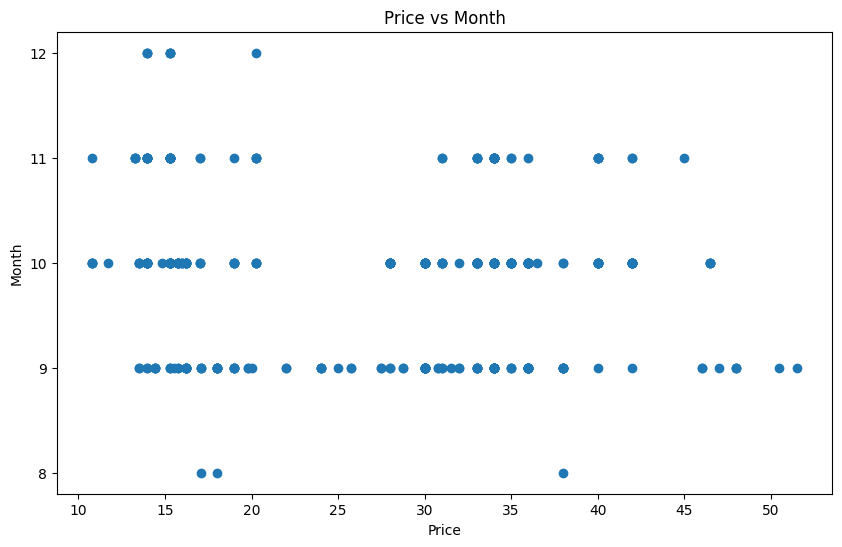

In [22]:
price = new_pumpkins.Price
month = new_pumpkins.Month
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(price, month)

ax.set_xlabel("Price")
ax.set_ylabel("Month")
ax.set_yticks(range(new_pumpkins.Month.min(), new_pumpkins.Month.max() + 1))
ax.set_title("Price vs Month")

plt.show()

### Make it useful
Create a plot where the x-axis shows the months, and the data demonstrates the distribution of data.<br/>
Group the data by each separate month and then take the average of the price for each month and plot it as a bar chart.

Text(0.5, 1.0, 'Average Pumpkin Price by Month')

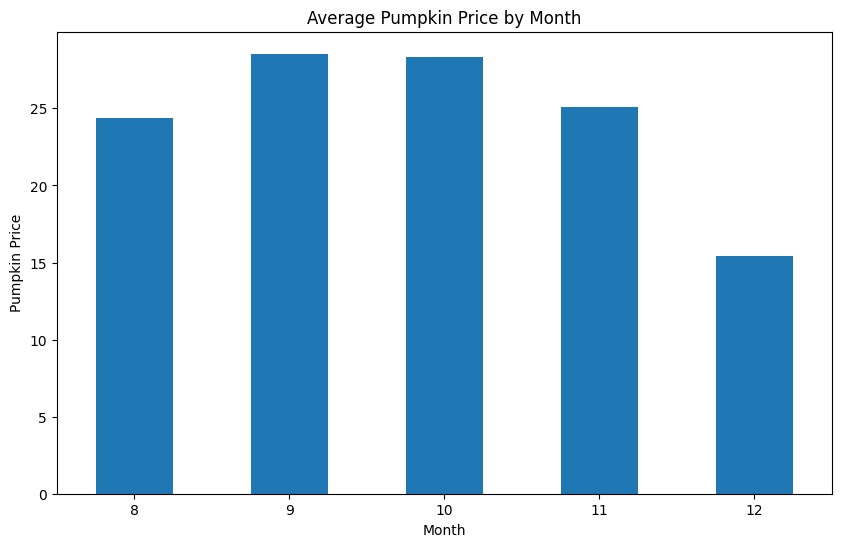

In [31]:
new_pumpkins.groupby("Month").Price.mean().plot(kind="bar", figsize=(10, 6))
ax = plt.gca()
ax.set_ylabel("Pumpkin Price")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_title("Average Pumpkin Price by Month")

The bar chart indicates that the highest price for pumpkins occurs in September and October.